# Library 

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\minhh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Get the dataset

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Check the dataset

In [5]:
df.isnull().sum()
df.duplicated().sum()
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Clean the dataset


In [6]:
def remove_html(text):
    clean = re.sub(r'<.*?>', '', text)
    return clean

In [7]:
def remove_special_char(text):
    clean = re.sub(r'[^a-zA-Z\s]', '', text)
    return clean

In [8]:
def tokenize(text):
    token = text.split()
    return token

In [9]:
def clean_text(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    token = tokenize(text)
    return token

# Normalization 

In [10]:
stop_word = set(stopwords.words('english'))

def remove_stopword(text):
    filtered = [word for word in text if word not in stop_word]
    return filtered

In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):

    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize(text_list):
    result = []

    tagged_words = nltk.pos_tag(text_list)
    
    for word, tag in tagged_words:
        wntag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wntag)
        result.append(lemma)
        
    return result

# Checkpoint testing

In [12]:
def preprocessing(text):
    text = remove_html(text)
    text = remove_special_char(text)
    text = text.lower()
    tokens = tokenize(text)
    
    tokens = remove_stopword(tokens)
    tokens = lemmatize(tokens)
    return tokens

# Get the data column and make it usable

In [13]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df['clean'] = df['review'].apply(lambda r: ' '.join(preprocessing(r)))

In [14]:
df.head()

,review,sentiment,label,clean
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mention watch oz episode youll ho...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,1,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love time money visually stunni...


# Train and test data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (40000,)
Test size: (10000,)


# Logistic Regression

## One Hot Encoding

In [16]:
encoder = CountVectorizer(binary=True)

X_train_encoded=encoder.fit_transform(X_train)
X_test_encoded=encoder.transform(X_test)

In [17]:
text_pipeline_log_one = Pipeline(
    steps=[
        ("encoding", CountVectorizer(binary=True,stop_words='english', ngram_range=(1, 2))),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_one.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [18]:
y_pred_log_one = text_pipeline_log_one.predict(X_test)
y_proba_log_one = text_pipeline_log_one.predict_proba(X_test)

In [19]:
results_log_one = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_log_one,
    "predicted_probability_positive": y_proba_log_one[:,1]
})

results_log_one.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,0.227875
1,0,1,0.679669
2,1,1,0.999173
3,0,0,0.021815
4,0,0,0.051950
5,0,0,0.000123
6,0,0,0.000384
7,0,1,0.786825
8,0,0,0.253769
9,0,0,0.000001


#### Accuracy, Precision, Recall, F1-score of OneHotEncoding

In [20]:
accuracy_log_one = accuracy_score(y_test, y_pred_log_one)
precision_log_one = precision_score(y_test, y_pred_log_one)
recall_log_one = recall_score(y_test, y_pred_log_one)
f1_log_one = f1_score(y_test, y_pred_log_one)

print(f"Accuracy:  {accuracy_log_one}")
print(f"Precision: {precision_log_one}")
print(f"Recall:    {recall_log_one}")
print(f"F1-score:  {f1_log_one}")

Accuracy:  0.8916
Precision: 0.8848270440251572
Recall:    0.9004
F1-score:  0.8925455987311658


In [21]:
print(classification_report(
    y_test,
    y_pred_log_one,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#### Error analysis 

In [22]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_one
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)


,message,true,predicted
39791,story bride fair amuse engage one filmmaker cr...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectation watch friend me...,1,0
40714,little quentin seem mastered art cake eat itas...,0,1
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
7266,farrah fawcett give award nominated performanc...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
48388,order enjoy fur imaginary portrait diane arbus...,0,1
20169,quite fan novelistscreenwriter michael chabon ...,0,1


#### Confusion matrix of OneHotEncoding

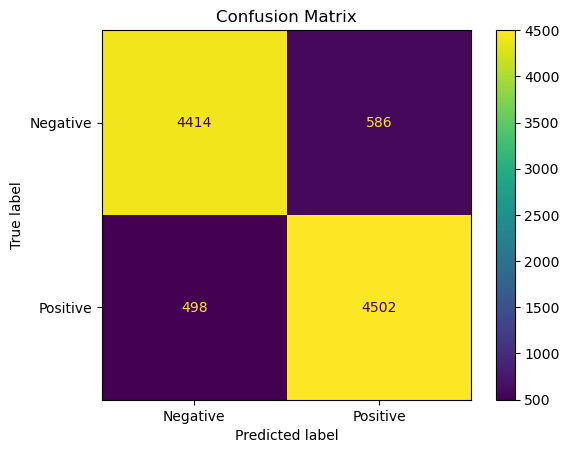

In [23]:
cm_log_one = confusion_matrix(y_test, y_pred_log_one)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_one,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Bag of Words

In [24]:
counter = CountVectorizer()

X_train_counted = counter.fit_transform(X_train)
X_test_counted = counter.transform(X_test)

In [25]:

text_pipeline_log_bag = Pipeline(
    steps=[
        ("bagging", CountVectorizer(stop_words='english', ngram_range=(1, 2))),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_bag.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('bagging', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [26]:
y_pred_log_bag = text_pipeline_log_bag.predict(X_test)
y_proba_log_bag = text_pipeline_log_bag.predict_proba(X_test)

In [27]:
results_log_bag = pd.DataFrame({
    "true_result": y_test.values,
    "predicted_class": y_pred_log_bag,
    "predicted_probability_positive": y_proba_log_bag[:,1]
})

results_log_bag.head(10)

,true_result,predicted_class,predicted_probability_positive
0,0,0,4.580902e-01
1,0,1,6.949622e-01
2,1,1,9.988959e-01
3,0,0,5.694297e-02
4,0,0,8.507734e-02
5,0,0,2.529597e-04
6,0,0,6.362991e-04
7,0,1,8.204243e-01
8,0,0,2.352621e-01
9,0,0,4.122328e-08


#### Accuracy, Precision, Recall, F1-score of Bag of Words

In [28]:
accuracy_log_bag = accuracy_score(y_test, y_pred_log_bag)
precision_log_bag = precision_score(y_test, y_pred_log_bag)
recall_log_bag = recall_score(y_test, y_pred_log_bag)
f1_log_bag = f1_score(y_test, y_pred_log_bag)

print(f"Accuracy:  {accuracy_log_bag}")
print(f"Precision: {precision_log_bag}")
print(f"Recall:    {recall_log_bag}")
print(f"F1-score:  {f1_log_bag}")

Accuracy:  0.8914
Precision: 0.8828247261345853
Recall:    0.9026
F1-score:  0.8926028481012658


In [29]:
print(classification_report(
    y_test,
    y_pred_log_bag,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#### Error analysis

In [30]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_bag
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
39791,story bride fair amuse engage one filmmaker cr...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectation watch friend me...,1,0
40714,little quentin seem mastered art cake eat itas...,0,1
31882,film list make film available something weird ...,0,1
1591,great movie tho cast especially kid admirably ...,1,0
7266,farrah fawcett give award nominated performanc...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
20169,quite fan novelistscreenwriter michael chabon ...,0,1
26800,tenshu imprison sentence death survives electr...,1,0


#### Confusion matrix of Bag of Words

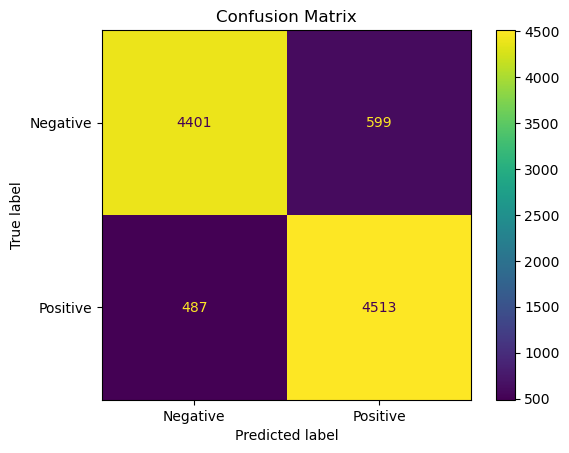

In [31]:
cm_log_bag = confusion_matrix(y_test, y_pred_log_bag)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_bag,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## TF-IDF

In [32]:
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [33]:
text_pipeline_log_tfidf = Pipeline(
    steps=[
        ("vectorizing", TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

text_pipeline_log_tfidf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [34]:
y_pred_log_tfidf = text_pipeline_log_tfidf.predict(X_test)
y_proba_log_tfidf = text_pipeline_log_tfidf.predict_proba(X_test)

In [35]:
results_log_tfidf = pd.DataFrame({
    "true results": y_test.values,
    "predicted_class": y_pred_log_tfidf,
    "predicted_probability_positive": y_proba_log_tfidf[:,1]
})

results_log_tfidf.head(10)

,true results,predicted_class,predicted_probability_positive
0,0,0,0.469001
1,0,1,0.671415
2,1,1,0.825129
3,0,0,0.333842
4,0,0,0.191850
5,0,0,0.107931
6,0,0,0.215593
7,0,1,0.653972
8,0,0,0.366331
9,0,0,0.037647


#### Accuracy, Precision, Recall, F1-score of TF - IDF

In [36]:
accuracy_log_tfidf = accuracy_score(y_test, y_pred_log_tfidf)
precision_log_tfidf = precision_score(y_test, y_pred_log_tfidf)
recall_log_tfidf = recall_score(y_test, y_pred_log_tfidf)
f1_log_tfidf = f1_score(y_test, y_pred_log_tfidf)

print(f"Accuracy:  {accuracy_log_tfidf}")
print(f"Precision: {precision_log_tfidf}")
print(f"Recall:    {recall_log_tfidf}")
print(f"F1-score:  {f1_log_tfidf}")

Accuracy:  0.8832
Precision: 0.8714618069019
Recall:    0.899
F1-score:  0.8850167355778696


In [37]:
print(classification_report(
    y_test,
    y_pred_log_tfidf,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      5000
    Positive       0.87      0.90      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



#### Error analysis

In [40]:
results = pd.DataFrame({
    "message": X_test,
    "true": y_test,
    "predicted": y_pred_log_tfidf
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(15)

,message,true,predicted
39791,story bride fair amuse engage one filmmaker cr...,0,1
40882,movie really wack really nothing nice say besi...,0,1
41611,admit create great expectation watch friend me...,1,0
40714,little quentin seem mastered art cake eat itas...,0,1
31882,film list make film available something weird ...,0,1
7266,farrah fawcett give award nominated performanc...,1,0
4142,movie gung ho story carlsons makin island raid...,0,1
11840,know brad linaweaver florida state u early ins...,0,1
48388,order enjoy fur imaginary portrait diane arbus...,0,1
20169,quite fan novelistscreenwriter michael chabon ...,0,1


#### Confusion matrix of TF-IDF

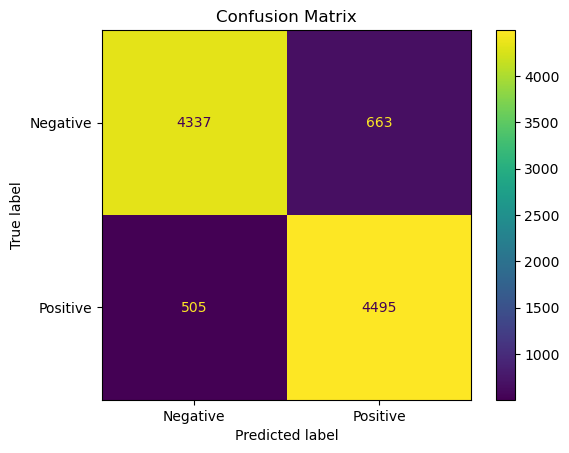

In [38]:
cm_log_tfidf = confusion_matrix(y_test, y_pred_log_tfidf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_tfidf,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()